# 6CS012 – Tutorial 7
# Denoising Convolutional Autoencoder – Devnagari Handwritten Digit Dataset

**Objective:** Build a deep (≥ 4 layer) Convolutional Autoencoder to remove Gaussian noise
from Devnagari handwritten digit images using unsupervised representation learning.

### Pipeline
1. Install & import libraries
2. Load & preprocess the Devnagari dataset
3. Add Gaussian noise
4. Build the deep Convolutional Autoencoder (Encoder + Decoder)
5. Train the model
6. Plot training / validation loss curves
7. Evaluate & visualise results
8. Experiment – vary architecture, noise level and training parameters

## Step 0 – Mount Google Drive (Colab only)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/AI_Sem6/Week 4 - Multi Layer Neural Network/Copy of devnagari digit.zip'
extraction_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f'Dataset unzipped to: {extraction_path}')

# Update DATASET_PATH to point to the unzipped directory
DATASET_PATH = '/content/DevanagariHandwrittenDigitDataset'

Dataset unzipped to: /content/


## Step 1 – Install & Import Libraries

In [5]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import random

# ── Numerical / image ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility seed ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print('All libraries imported successfully!')

TensorFlow version : 2.20.0
All libraries imported successfully!


## Step 2 – Load & Preprocess the Devnagari Dataset

The Devnagari Handwritten Digit dataset contains 32×32 grayscale images of digits 0–9
in Devnagari script (used in Nepali / Hindi writing systems).  
Update `DATASET_PATH` to point to the root folder on your Drive.

**Expected folder layout:**
```
DevanagariHandwrittenCharacterDataset/
    Train/
        digit_0/  *.png
        digit_1/  *.png
        ...
    Test/
        digit_0/  *.png
        ...
```

In [8]:
# ── Configuration ────────────────────────────────────────────────────────────
# Update this path to where your dataset sits on Google Drive
DATASET_PATH = "/content/DevanagariHandwrittenDigitDataset"
IMG_SIZE     = 32          # Devnagari images are 32x32
CHANNELS     = 1           # grayscale
MAX_PER_CLASS = 500        # cap per class to speed up Colab training (set None for all)


def load_devnagari(root_path, split="Train", img_size=32, max_per_class=None):
    """
    Recursively walk the dataset folder and load images as normalised
    NumPy arrays of shape (N, img_size, img_size, 1).

    Args:
        root_path     : path to dataset root
        split         : 'Train' or 'Test'
        img_size      : target image size (square)
        max_per_class : optional cap on images per class

    Returns:
        images (np.ndarray), labels (np.ndarray)
    """
    split_path = os.path.join(root_path, split)
    images, labels = [], []

    class_dirs = sorted(os.listdir(split_path))
    for label_idx, class_name in enumerate(class_dirs):
        class_dir = os.path.join(split_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if max_per_class:
            files = files[:max_per_class]
        for fname in files:
            img_path = os.path.join(class_dir, fname)
            try:
                img = Image.open(img_path).convert('L')          # grayscale
                img = img.resize((img_size, img_size), Image.LANCZOS)
                images.append(np.array(img, dtype=np.float32))
                labels.append(label_idx)
            except Exception as e:
                print(f'  Skipping {fname}: {e}')

    images = np.array(images) / 255.0               # normalise to [0, 1]
    images = images[..., np.newaxis]                 # add channel dim → (N, H, W, 1)
    labels = np.array(labels)
    return images, labels


# ── Load ─────────────────────────────────────────────────────────────────────
print('Loading training images ...')
x_all, y_all = load_devnagari(DATASET_PATH, split='Train',
                               img_size=IMG_SIZE, max_per_class=MAX_PER_CLASS)

print(f'Total images loaded : {x_all.shape[0]}')
print(f'Image shape         : {x_all.shape[1:]}')
print(f'Pixel range         : [{x_all.min():.2f}, {x_all.max():.2f}]')

Loading training images ...
Total images loaded : 5000
Image shape         : (32, 32, 1)
Pixel range         : [0.00, 1.00]


Training   samples : 4250
Validation samples : 750


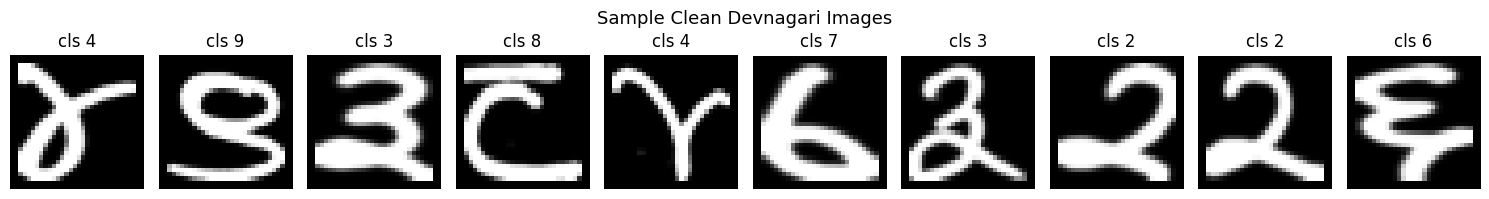

In [9]:
# ── Train / Validation split ─────────────────────────────────────────────────
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all,
    test_size=0.15,
    random_state=SEED,
    stratify=y_all
)

print(f'Training   samples : {x_train.shape[0]}')
print(f'Validation samples : {x_val.shape[0]}')

# ── Quick peek at 10 clean samples ──────────────────────────────────────────
plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f'cls {y_train[i]}')
    plt.axis('off')
plt.suptitle('Sample Clean Devnagari Images', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 – Add Gaussian Noise

We experiment with **two noise levels** so we can compare model performance later.

| Variable | Noise factor | Description |
|---|---|---|
| `*_noisy_low` | 0.1 | mild noise |
| `*_noisy_high` | 0.4 | heavy noise (used for training) |

Noise added successfully.


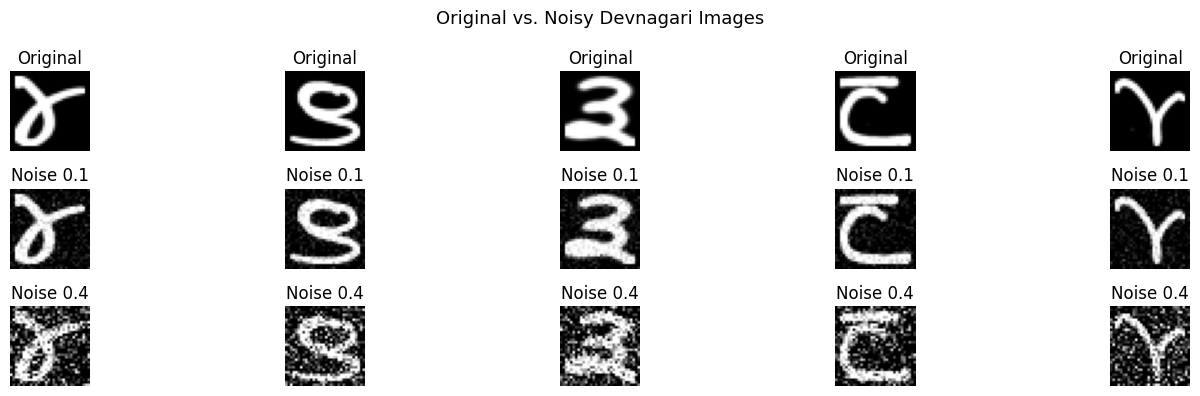

In [10]:
def add_gaussian_noise(images, noise_factor):
    """
    Add zero-mean Gaussian noise to a batch of images and clip to [0, 1].

    Args:
        images       : np.ndarray of shape (N, H, W, C), values in [0, 1]
        noise_factor : standard deviation scale of the noise

    Returns:
        Noisy images clipped to [0, 1]
    """
    noise = noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    ).astype(np.float32)
    return np.clip(images + noise, 0.0, 1.0)


NOISE_LOW  = 0.1
NOISE_HIGH = 0.4

x_train_noisy_low  = add_gaussian_noise(x_train, NOISE_LOW)
x_train_noisy_high = add_gaussian_noise(x_train, NOISE_HIGH)
x_val_noisy_low    = add_gaussian_noise(x_val,   NOISE_LOW)
x_val_noisy_high   = add_gaussian_noise(x_val,   NOISE_HIGH)

print('Noise added successfully.')

# ── Visualise original vs. two noise levels ──────────────────────────────────
n_show = 5
plt.figure(figsize=(15, 4))
for i in range(n_show):
    # Original
    plt.subplot(3, n_show, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    # Low noise
    plt.subplot(3, n_show, i + 1 + n_show)
    plt.imshow(x_train_noisy_low[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f'Noise {NOISE_LOW}')
    plt.axis('off')
    # High noise
    plt.subplot(3, n_show, i + 1 + 2 * n_show)
    plt.imshow(x_train_noisy_high[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f'Noise {NOISE_HIGH}')
    plt.axis('off')

plt.suptitle('Original vs. Noisy Devnagari Images', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 – Build the Deep Convolutional Autoencoder

The architecture is **at least 4 layers deep** as required by the exercise.

### Encoder (compress 32×32 → 4×4 latent map)
| Layer | Filters | Output shape |
|---|---|---|
| Conv2D + BN + ReLU | 32 | 32×32×32 |
| MaxPooling2D (2×2) | — | 16×16×32 |
| Conv2D + BN + ReLU | 64 | 16×16×64 |
| MaxPooling2D (2×2) | — | 8×8×64 |
| Conv2D + BN + ReLU | 128 | 8×8×128 |
| MaxPooling2D (2×2) | — | **4×4×128** (latent Z) |

### Decoder (reconstruct 4×4 → 32×32)
| Layer | Filters | Output shape |
|---|---|---|
| Conv2D + BN + ReLU | 128 | 4×4×128 |
| UpSampling2D (2×2) | — | 8×8×128 |
| Conv2D + BN + ReLU | 64 | 8×8×64 |
| UpSampling2D (2×2) | — | 16×16×64 |
| Conv2D + BN + ReLU | 32 | 16×16×32 |
| UpSampling2D (2×2) | — | 32×32×32 |
| Conv2D + sigmoid | 1 | **32×32×1** (reconstructed) |

In [11]:
def build_encoder(input_shape=(32, 32, 1)):
    """
    Builds the encoder: 3 conv blocks + maxpooling, ending at a 4x4 latent map.

    Args:
        input_shape (tuple): Shape of input image. Default (32, 32, 1).

    Returns:
        input_img (Keras Input): Input layer.
        encoded   (Keras Tensor): Latent representation Z.
    """
    input_img = Input(shape=input_shape, name='encoder_input')

    # ── Block 1 ────────────────────────────────────────────────────────────
    x = Conv2D(32, (3, 3), padding='same', name='enc_conv1')(input_img)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)  # 16x16x32

    # ── Block 2 ────────────────────────────────────────────────────────────
    x = Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)  # 8x8x64

    # ── Block 3 ────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), padding='same', name='enc_conv3')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='encoded')(x)  # 4x4x128

    return input_img, encoded


def build_decoder(encoded_input):
    """
    Builds the decoder: 3 conv blocks + upsampling, reconstructing to 32x32x1.

    Args:
        encoded_input (Keras Tensor): Output from the encoder (4x4x128).

    Returns:
        decoded (Keras Tensor): Reconstructed image (32x32x1), sigmoid activation.
    """
    # ── Block 1 ────────────────────────────────────────────────────────────
    x = Conv2D(128, (3, 3), padding='same', name='dec_conv1')(encoded_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2, 2), name='dec_up1')(x)   # 8x8x128

    # ── Block 2 ────────────────────────────────────────────────────────────
    x = Conv2D(64, (3, 3), padding='same', name='dec_conv2')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2, 2), name='dec_up2')(x)   # 16x16x64

    # ── Block 3 ────────────────────────────────────────────────────────────
    x = Conv2D(32, (3, 3), padding='same', name='dec_conv3')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2, 2), name='dec_up3')(x)   # 32x32x32

    # ── Output layer ────────────────────────────────────────────────────────
    decoded = Conv2D(1, (3, 3), activation='sigmoid',
                     padding='same', name='decoder_output')(x)  # 32x32x1
    return decoded


def build_autoencoder(input_shape=(32, 32, 1), learning_rate=1e-3):
    """
    Constructs and compiles the full Denoising Convolutional Autoencoder.

    Args:
        input_shape   : Shape of input image. Default (32, 32, 1).
        learning_rate : Adam optimizer learning rate.

    Returns:
        autoencoder (Keras Model): Compiled model ready for training.
    """
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output             = build_decoder(encoded_output)

    autoencoder = Model(
        inputs=input_img,
        outputs=decoded_output,
        name='denoising_autoencoder'
    )
    autoencoder.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy'
    )
    return autoencoder


# ── Build & summarise ────────────────────────────────────────────────────────
autoencoder = build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 334,593 (1.28 MB)

 Trainable params: 333,697 (1.27 MB)

 Non-trainable params: 896 (3.50 KB)

## Step 5 – Train the Autoencoder

- **Input**  → noisy images (`x_train_noisy_high`)
- **Target** → clean images (`x_train`)

Two Keras callbacks are used:
- `EarlyStopping` – stops training when val_loss stops improving (patience = 5)
- `ReduceLROnPlateau` – halves the learning rate when val_loss plateaus (patience = 3)

In [12]:
# ── Callbacks ────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ── Training ─────────────────────────────────────────────────────────────────
EPOCHS     = 30
BATCH_SIZE = 64

history = autoencoder.fit(
    x_train_noisy_high, x_train,       # noisy input → clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy_high, x_val),
    callbacks=[early_stop, reduce_lr]
)

print('Training complete!')

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - loss: 0.2618 - val_loss: 0.3952 - learning_rate: 0.0010
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 475ms/step - loss: 0.1737 - val_loss: 0.5673 - learning_rate: 0.0010
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 491ms/step - loss: 0.1564 - val_loss: 0.5317 - learning_rate: 0.0010
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 489ms/step - loss: 0.1487 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 493ms/step - loss: 0.1441 - val_loss: 0.2441 - learning_rate: 0.0010
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 476ms/step - loss: 0.1411 - val_loss: 0.1883 - learning_rate: 0.0010
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 467ms/step - loss: 0.1399 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 478ms/step - loss: 0.1399 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 9/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 478ms/step - loss: 0.1374 - val_loss: 0.1512 - learning_rate: 0.0010
E

## Step 6 – Plot Training & Validation Loss Curves

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=13)
plt.title('Denoising Autoencoder – Training and Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss']) + 1
best_loss  = min(history.history['val_loss'])
print(f'Best validation loss {best_loss:.4f} at epoch {best_epoch}')

## Step 7 – Evaluate & Visualise Results

Display three rows per sample:
1. **Noisy image** (model input)
2. **Denoised image** (model output)
3. **Clean image** (ground truth)

Denoised image array shape: (750, 32, 32, 1)


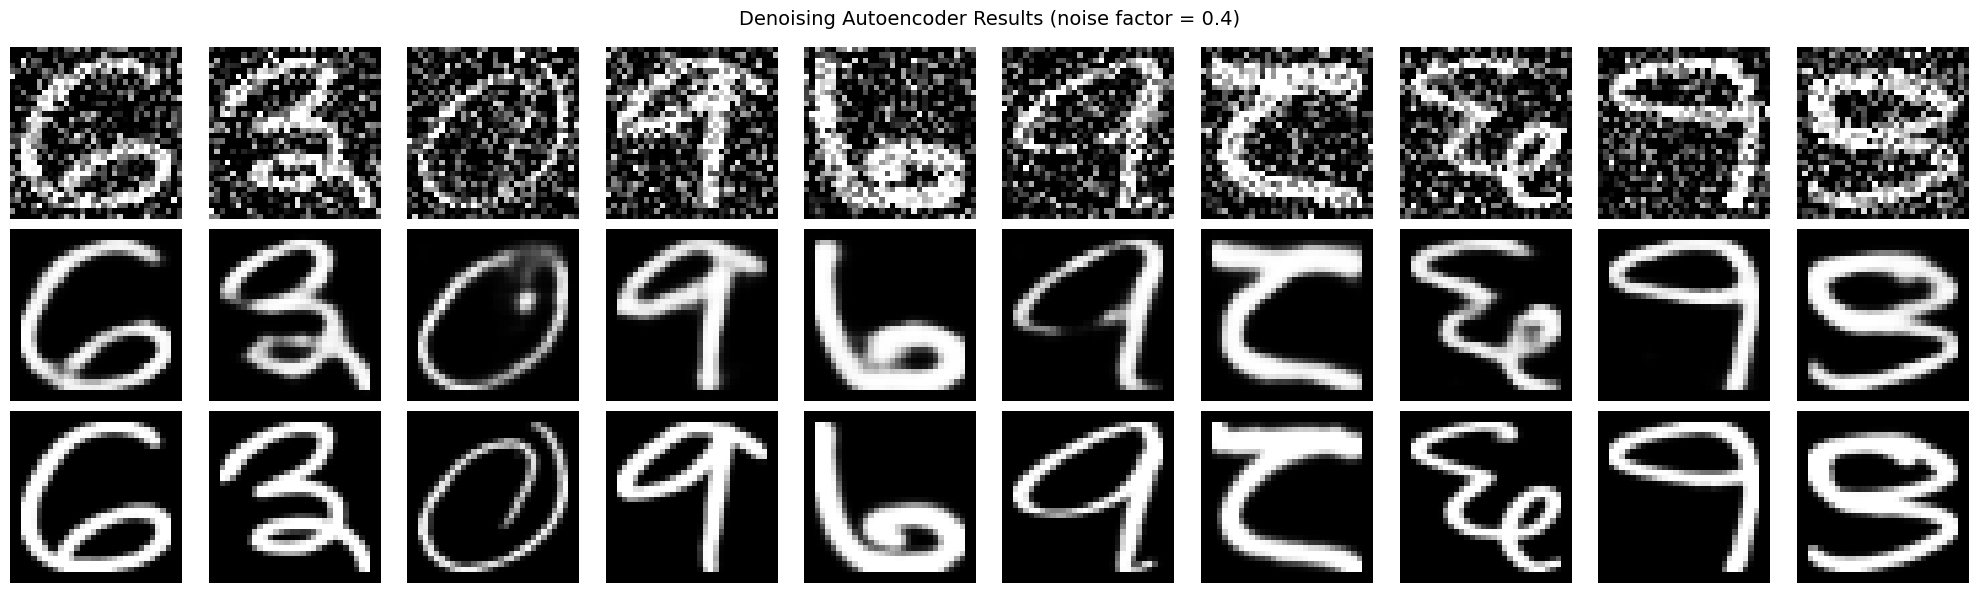

In [13]:
# ── Predict denoised images ───────────────────────────────────────────────────
denoised_images = autoencoder.predict(x_val_noisy_high, batch_size=64, verbose=0)
print(f'Denoised image array shape: {denoised_images.shape}')


def plot_results(noisy, denoised, clean, n=10, title='Denoising Results'):
    """
    Plot n samples of: noisy → denoised → clean.

    Args:
        noisy    : np.ndarray of noisy images   (N, H, W, 1)
        denoised : np.ndarray of denoised images (N, H, W, 1)
        clean    : np.ndarray of clean images   (N, H, W, 1)
        n        : number of samples to display
        title    : figure title string
    """
    plt.figure(figsize=(2 * n, 6))
    row_labels = ['Noisy (Input)', 'Denoised (Output)', 'Clean (Target)']
    arrays     = [noisy, denoised, clean]

    for row_idx, (arr, row_label) in enumerate(zip(arrays, row_labels)):
        for col_idx in range(n):
            ax = plt.subplot(3, n, row_idx * n + col_idx + 1)
            ax.imshow(arr[col_idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=5)
            ax.axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_results(
    x_val_noisy_high[:10],
    denoised_images[:10],
    x_val[:10],
    n=10,
    title=f'Denoising Autoencoder Results (noise factor = {NOISE_HIGH})'
)

In [14]:
# ── Quantitative evaluation: Mean Squared Error ──────────────────────────────
mse_noisy    = np.mean((x_val - x_val_noisy_high) ** 2)
mse_denoised = np.mean((x_val - denoised_images)  ** 2)

print('=' * 45)
print(f'  MSE (Noisy    vs Clean) : {mse_noisy:.4f}')
print(f'  MSE (Denoised vs Clean) : {mse_denoised:.4f}')
print(f'  MSE Improvement         : {(1 - mse_denoised / mse_noisy) * 100:.1f} %')
print('=' * 45)

  MSE (Noisy    vs Clean) : 0.0804
  MSE (Denoised vs Clean) : 0.0124
  MSE Improvement         : 84.6 %


## Step 8 – Experiment: Vary Architecture, Noise Level & Training Parameters

We now train **three variants** and compare their denoising MSE:

| Experiment | Change |
|---|---|
| A (baseline) | Original model, noise = 0.4 |
| B | Lower noise (0.2) – easier task |
| C | Deeper model (extra conv block), noise = 0.4 |

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# Experiment B – same architecture, lower noise factor
# ──────────────────────────────────────────────────────────────────────────────
NOISE_EXP_B = 0.2
x_train_noisy_b = add_gaussian_noise(x_train, NOISE_EXP_B)
x_val_noisy_b   = add_gaussian_noise(x_val,   NOISE_EXP_B)

model_b = build_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
history_b = model_b.fit(
    x_train_noisy_b, x_train,
    epochs=20,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy_b, x_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                              restore_best_weights=True, verbose=0)],
    verbose=1
)
denoised_b  = model_b.predict(x_val_noisy_b, verbose=0)
mse_b       = np.mean((x_val - denoised_b) ** 2)
print(f'[Exp B] noise={NOISE_EXP_B}  →  MSE (denoised vs clean) = {mse_b:.4f}')

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 46s 591ms/step - loss: 0.3118 - val_loss: 0.5776
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 488ms/step - loss: 0.1724 - val_loss: 0.8473
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 473ms/step - loss: 0.1508 - val_loss: 0.9757
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - loss: 0.1413 - val_loss: 0.7582
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 34s 504ms/step - loss: 0.1362 - val_loss: 0.4177
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 500ms/step - loss: 0.1329 - val_loss: 0.2221
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 41s 501ms/step - loss: 0.1306 - val_loss: 0.1547
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 479ms/step - loss: 0.1285 - val_loss: 0.1392
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 32s 481ms/step - loss: 0.1270 - val_loss: 0.1335
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - loss: 0.1260 - val_loss: 0.1317
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 33s 489ms/step - loss: 0.1252 - val_loss: 0.1318
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 40

In [16]:
# ──────────────────────────────────────────────────────────────────────────────
# Experiment C – deeper model (4-block encoder/decoder)
# ──────────────────────────────────────────────────────────────────────────────
def build_deeper_autoencoder(input_shape=(32, 32, 1), learning_rate=1e-3):
    """
    Deeper variant: 4-block encoder/decoder for richer feature extraction.
    Adds an extra Conv2D block (256 filters) before the latent space.
    """
    input_img = Input(shape=input_shape, name='input_deep')

    # ── Encoder ──────────────────────────────────────────────────────────
    x = Conv2D(32,  (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)     # 16x16x32

    x = Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)     # 8x8x64

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)     # 4x4x128

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='encoded_deep')(x)  # 2x2x256

    # ── Decoder ──────────────────────────────────────────────────────────
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)     # 4x4x256

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)     # 8x8x128

    x = Conv2D(64,  (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)     # 16x16x64

    x = Conv2D(32,  (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)     # 32x32x32

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output_deep')(x)

    model = Model(inputs=input_img, outputs=decoded, name='deeper_autoencoder')
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy')
    return model


model_c = build_deeper_autoencoder(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
model_c.summary()

history_c = model_c.fit(
    x_train_noisy_high, x_train,
    epochs=20,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy_high, x_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=4,
                              restore_best_weights=True, verbose=0)],
    verbose=1
)
denoised_c = model_c.predict(x_val_noisy_high, verbose=0)
mse_c      = np.mean((x_val - denoised_c) ** 2)
print(f'[Exp C] deeper model, noise={NOISE_HIGH}  →  MSE = {mse_c:.4f}')

Model: "deeper_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_deep (InputLayer)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_deep (MaxPooling2D)     │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_deep (Conv2D)            │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,505 (5.21 MB)

 Trainable params: 1,365,505 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 53s 716ms/step - loss: 0.5215 - val_loss: 0.4626
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 692ms/step - loss: 0.4290 - val_loss: 0.3749
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 82s 687ms/step - loss: 0.3315 - val_loss: 0.2905
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 87s 763ms/step - loss: 0.2631 - val_loss: 0.2491
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 771ms/step - loss: 0.2339 - val_loss: 0.2269
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 48s 719ms/step - loss: 0.2186 - val_loss: 0.2252
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 79s 682ms/step - loss: 0.2067 - val_loss: 0.2159
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 47s 706ms/step - loss: 0.1962 - val_loss: 0.1996
Epoch 9/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 81s 681ms/step - loss: 0.1869 - val_loss: 0.1930
Epoch 10/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 82s 684ms/step - loss: 0.1821 - val_loss: 0.2046
Epoch 11/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 46s 682ms/step - loss: 0.1814 - val_loss: 0.1880
Epoch 12/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 82


Experiment                                 MSE
A – Baseline (noise=0.4)                0.0124
B – Lower noise (noise=0.2)             0.0081
C – Deeper model (noise=0.4)            0.0219


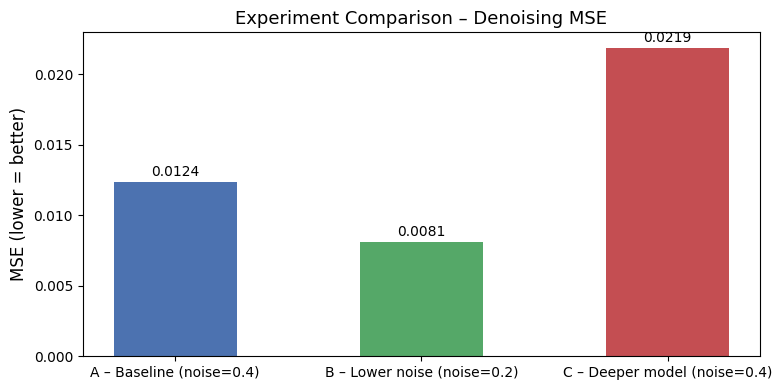

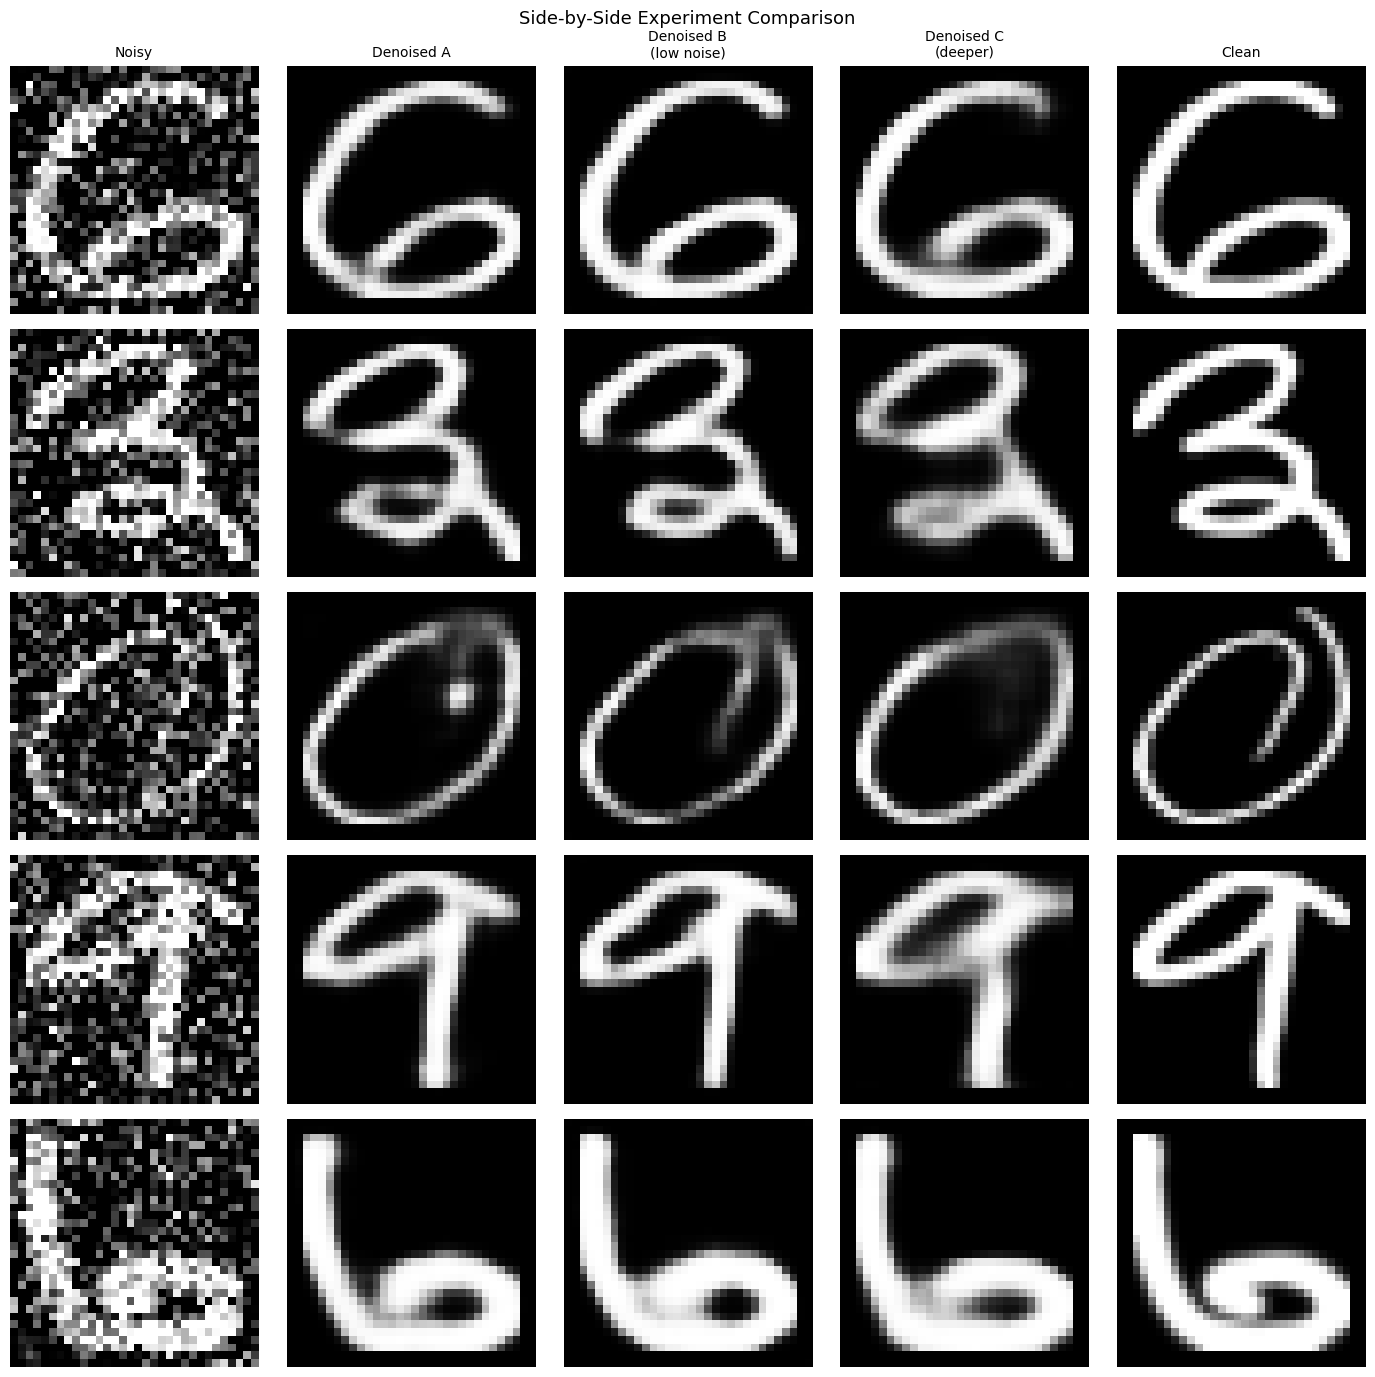

In [17]:
# ── Summary comparison ────────────────────────────────────────────────────────
experiments = {
    'A – Baseline (noise=0.4)'        : mse_denoised,
    'B – Lower noise (noise=0.2)'     : mse_b,
    'C – Deeper model (noise=0.4)'    : mse_c,
}

print('\n' + '=' * 50)
print(f'{"Experiment":<35} {"MSE":>10}')
print('=' * 50)
for name, mse in experiments.items():
    print(f'{name:<35} {mse:>10.4f}')
print('=' * 50)

# Bar chart
plt.figure(figsize=(8, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(experiments.keys(), experiments.values(), color=colors, width=0.5)
plt.ylabel('MSE (lower = better)', fontsize=12)
plt.title('Experiment Comparison – Denoising MSE', fontsize=13)
plt.xticks(fontsize=10)
for bar, val in zip(bars, experiments.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


# Visual comparison of all three models on same 5 images
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
col_titles = ['Noisy', 'Denoised A', 'Denoised B\n(low noise)', 'Denoised C\n(deeper)', 'Clean']
all_outputs = [x_val_noisy_high, denoised_images, denoised_b, denoised_c, x_val]

for row in range(5):
    for col, (arr, title) in enumerate(zip(all_outputs, col_titles)):
        axes[row][col].imshow(arr[row].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        if row == 0:
            axes[row][col].set_title(title, fontsize=10)
        axes[row][col].axis('off')

plt.suptitle('Side-by-Side Experiment Comparison', fontsize=13)
plt.tight_layout()
plt.show()